In [14]:
import sys

# Adds src/ to the import path so `import lts` finds src/lts.py. This assumes
# the notebook's working directory is the repo root, matching the bare
# "data/..." / "coeffs_heatmap/..." paths used elsewhere in this notebook.
# If your Jupyter cwd is this examples/ folder instead, use "../src".
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from scipy.integrate import solve_ivp
import lts

In [2]:
def load_data(data, noise_level, outlier_percent):
    temp = data[f'noise_{noise_level:g}'].item()
    return temp[f'data_{outlier_percent:g}'], temp[f'outInd_{outlier_percent:g}']

T_DCT = {
    'SIR': (0,100),
    'LV': (0,30),
    'LORENZ': (0,20),
}


def plot_data(data, outliers,t, case='SIR'):
    if case.upper() == 'LORENZ':
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(data[:, 0], data[:, 1], data[:, 2], 'bo', label='Inliers')
        if len(outliers) > 0:
            ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2], c='red', marker='x', s=50, label='Outliers')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend()
        plt.title('Lorenz System Data')
        plt.show()
    else:
        n_samples, n_dims = data.shape
        fig, axes = plt.subplots(n_dims, 1, figsize=(12, 3 * n_dims), sharex=True)
        axes = np.atleast_1d(axes).ravel()

        mask_out = np.zeros(n_samples, dtype=bool)
        if outliers is not None and len(outliers) > 0:
            out_arr = np.asarray(outliers)

            # 1) boolean mask
            if out_arr.dtype == bool and out_arr.shape[0] == n_samples:
                mask_out = out_arr.copy()

            # 2) integer indices
            elif out_arr.ndim == 1 and np.issubdtype(out_arr.dtype, np.integer):
                valid_idx = out_arr[(out_arr >= 0) & (out_arr < n_samples)]
                mask_out[valid_idx] = True

                # 3) outlier points (rows) with same dimensionality as data
            elif out_arr.ndim == 2 and out_arr.shape[1] == n_dims:
                data_view = np.ascontiguousarray(data).view([("", data.dtype)] * n_dims).ravel()
                out_view = np.ascontiguousarray(out_arr).view([("", out_arr.dtype)] * n_dims).ravel()
                mask_out = np.isin(data_view, out_view)

        
        for i, ax in enumerate(axes):
            ax.plot(t, data[:, i], "bo", label="Inliers")
            if mask_out.any():
                ax.scatter(t[mask_out], data[mask_out, i], s=50, c="red", marker="x", lw=3, label="Outliers")
                ax.set_ylabel(f"Dim {i}")
                ax.grid(alpha=0.3)
            if i == 0:
                ax.legend()

        axes[-1].set_xlabel("t")
        plt.suptitle(f"{case.upper()} Data")
        plt.tight_layout()
        plt.show()

In [3]:
def get_true_coeff(case, data):
    if case == 'SIR':
        functions = [
            lambda x: x,  # Identity function
            lambda x,y: x*y,  # Product function
        ]
        function_names = [
            lambda x: f'{x}',  # Identity function
            lambda x,y: f'{x}{y}',  # Product function:
        ]

        lib = ps.CustomLibrary(library_functions=functions, function_names=function_names)
    else:
        lib = ps.PolynomialLibrary(degree=3)

    lib.fit_transform(data)
    name_tag = lib.get_feature_names(['x', 'y', 'z'])
    true_coeff = np.zeros((len(name_tag), 3),dtype=float)
    if case == 'SIR':
        true_coeff[3,0] = -0.3
        true_coeff[3,1] = 0.3
        true_coeff[1,1] = -0.1
        true_coeff[1,2] = 0.1
    elif case == 'LORENZ':
        true_coeff[1, 0] = -10
        true_coeff[2, 0] = 10
        true_coeff[1, 1] = 28
        true_coeff[2, 1] = -1
        true_coeff[6, 1] = -1
        true_coeff[3, 2] = -8/3
        true_coeff[5, 2] = 1
        true_coeff[1, 0] = -10
        true_coeff[2, 0] = 10
        true_coeff[1, 1] = 28
        true_coeff[2, 1] = -1
        true_coeff[6, 1] = -1
        true_coeff[3, 2] = -8/3
        true_coeff[5, 2] = 1
    else:
        true_coeff = np.zeros((len(name_tag), 2),dtype=float)
        true_coeff[1,0] = 1.0
        true_coeff[4,0] = -0.1
        true_coeff[4,1] = 0.1
        true_coeff[2,1] = -2.0
    return true_coeff

def calculate_sindy_accuracy(true_coef, estimated_coef, tolerance=1e-3):
    """
    Calculate accuracy of SINDy coefficients using the formula:
    Accuracy = (TP + TN) / (TP + TN + FP + FN)

    Parameters:
    true_coef (np.ndarray): Ground truth coefficients
    estimated_coef (np.ndarray): Estimated coefficients
    tolerance (float): Threshold to consider a coefficient as zero

    Returns:
    float: Accuracy
    """
    # Convert coefficients to binary (1 if non-zero, 0 if zero within tolerance)
    true_binary = np.abs(true_coef) > tolerance
    estimated_binary = np.abs(estimated_coef) > tolerance

    # Calculate TP, TN, FP, FN
    tp = np.sum((true_binary == 1) & (estimated_binary == 1))
    tn = np.sum((true_binary == 0) & (estimated_binary == 0))
    fp = np.sum((true_binary == 0) & (estimated_binary == 1))
    fn = np.sum((true_binary == 1) & (estimated_binary == 0))


    # Calculate accuracy
    return (tp+tn)/(tp+tn+fp+fn)


In [4]:
def load_heatmap_coeff(data, noise_level, outlier_percent, is_lovo = False):
    temp = data[f'noise_{noise_level:g}'].item()
    coeff = temp[f'coeffs_{outlier_percent*100:g}']
    if is_lovo:
        td = temp[f'outliers_{outlier_percent*100:g}']
        return coeff, td
    return coeff

In [6]:
noise_list = np.linspace(0,0.2,9)[1:]
outlier_list = np.linspace(0,0.2,9)[1:]
solvers = ['SINDY', 'ESINDY', 'LOVO_LS']
models = ['SIR', 'LORENZ', 'LV']
results_matrix = np.zeros((len(models),len(solvers),8,8), dtype=float)
nsamples = 100
# solver = 'LOVO_LS'

for m, model in enumerate(models):
    data_file = np.load(f'data/{model}_heatmap_{nsamples}_data.npz', allow_pickle=True)
    data,_ = load_data(data_file,0,0)

    true_coeff = get_true_coeff(model, data)
    for k, solver in enumerate(solvers):
        p = 3 if solver.__contains__('LOVO_LS') else 0
        coeffs_file = np.load(f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz', allow_pickle=True)
        for i, nl in enumerate(noise_list):
            for j, op in enumerate(outlier_list):
                coeff_list = load_heatmap_coeff(coeffs_file, nl, op)
                acc_sum = 0
                for coeff in coeff_list:
                    acc_sum += calculate_sindy_accuracy(true_coeff, coeff)
                results_matrix[m,k,i,j] = acc_sum/nsamples

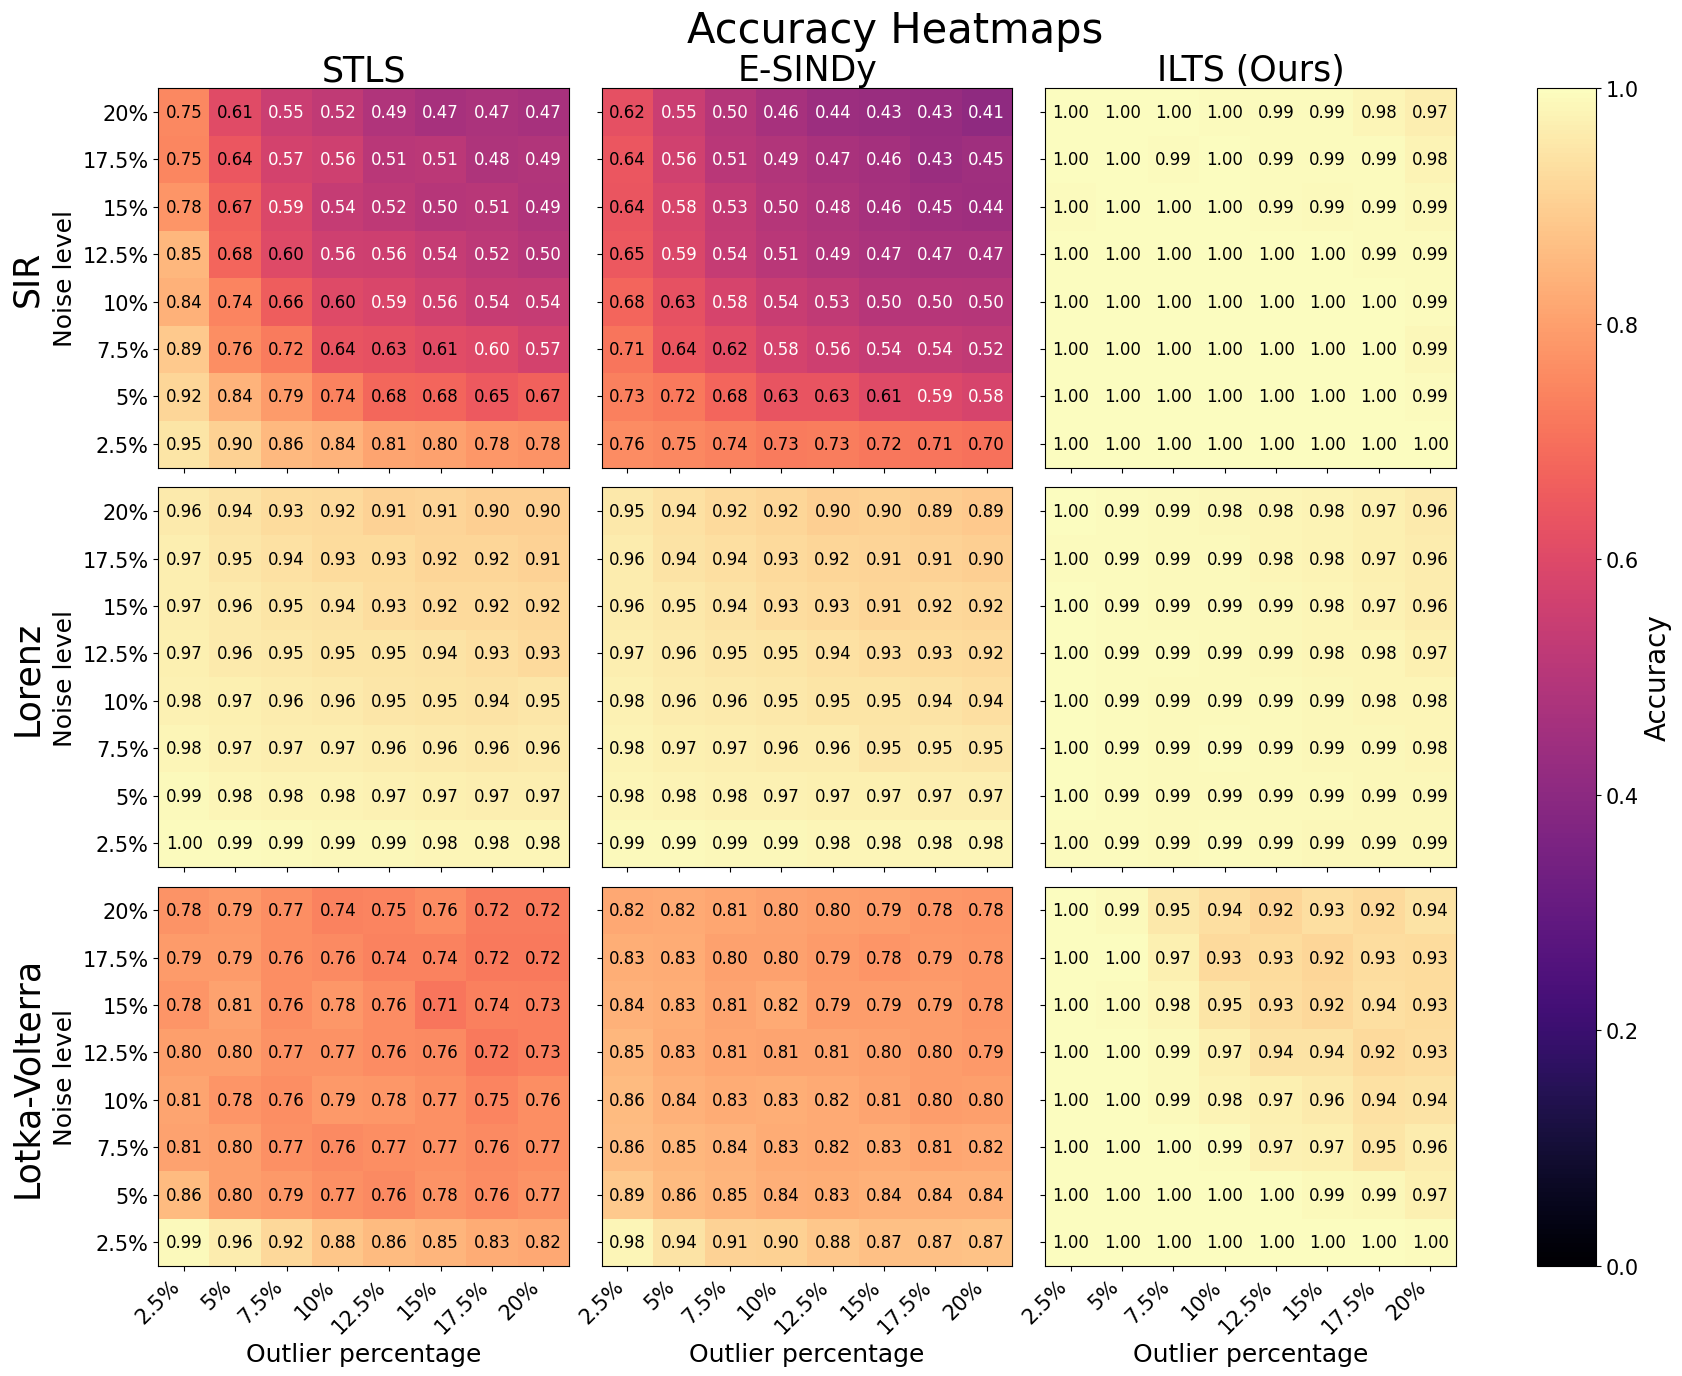

In [9]:
# Heatmap grid: rows = models, columns = solvers
solver_names = ['STLS', 'E-SINDy', 'ILTS (Ours)']
model_names = ['SIR', 'Lorenz', 'Lotka-Volterra']

fig, axes = plt.subplots(len(models), len(solvers), figsize=(18, 14), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for m_idx, model_name in enumerate(model_names):
    for s_idx, solver_name in enumerate(solver_names):
        ax = axes[m_idx, s_idx]
        acc = results_matrix[m_idx, s_idx]  # shape (8, 8)

        im = ax.imshow(acc, origin="lower", cmap="magma", vmin=0, vmax=1, aspect="auto")

        ax.set_xticks(np.arange(len(outlier_list)))
        ax.set_xticklabels([f"{v*100:g}%" for v in outlier_list], rotation=45, ha="right", fontsize=15)

        ax.set_yticks(np.arange(len(noise_list)))
        ax.set_yticklabels([f"{v*100:g}%" for v in noise_list], fontsize=15)

        if m_idx == len(models) - 1:
            ax.set_xlabel("Outlier percentage", fontsize=18)
        if s_idx == 0:
            ax.set_ylabel("Noise level", fontsize=18)
            ax.text(
                -0.32, 0.5, model_name,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center",
                fontsize=25
            )

        if m_idx == 0:
            ax.set_title(solver_name, fontsize=25)

        for r in range(acc.shape[0]):
            for c in range(acc.shape[1]):
                v = acc[r, c]
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=12, color="white" if v < 0.6 else "black")

fig.suptitle("Accuracy Heatmaps", fontsize=30)
fig.tight_layout()

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label="Accuracy")
cbar.ax.tick_params(labelsize=15)
cbar.set_label("Accuracy", size=20)

fig.savefig(f"paper_figs/heatmap/heatmap_all_models_{nsamples}_samples.pdf", format="pdf",bbox_inches='tight')
plt.show()

In [10]:
noise_list = np.linspace(0,0.2,9)[1:]
outlier_list = np.linspace(0,0.2,9)[1:]
solvers = ['SINDY', 'ESINDY', 'LOVO_LS']
models = ['SIR', 'LORENZ', 'LV']
results_matrix_hits = np.zeros((len(models),len(solvers),8,8), dtype=float)
nsamples = 100
# solver = 'LOVO_LS'

for m, model in enumerate(models):
    data_file = np.load(f'data/{model}_heatmap_{nsamples}_data.npz', allow_pickle=True)
    data,_ = load_data(data_file,0,0)

    true_coeff = get_true_coeff(model, data)
    for k, solver in enumerate(solvers):
        p = 3 if solver == 'LOVO_LS' else 0
        coeffs_file = np.load(f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz', allow_pickle=True)
        for i, nl in enumerate(noise_list):
            for j, op in enumerate(outlier_list):
                coeff_list = load_heatmap_coeff(coeffs_file, nl, op)
                hit_sum = 0
                for coeff in coeff_list:
                    hit_sum +=  1 if 1. == calculate_sindy_accuracy(true_coeff, coeff) else 0
                results_matrix_hits[m,k,i,j] = hit_sum/nsamples


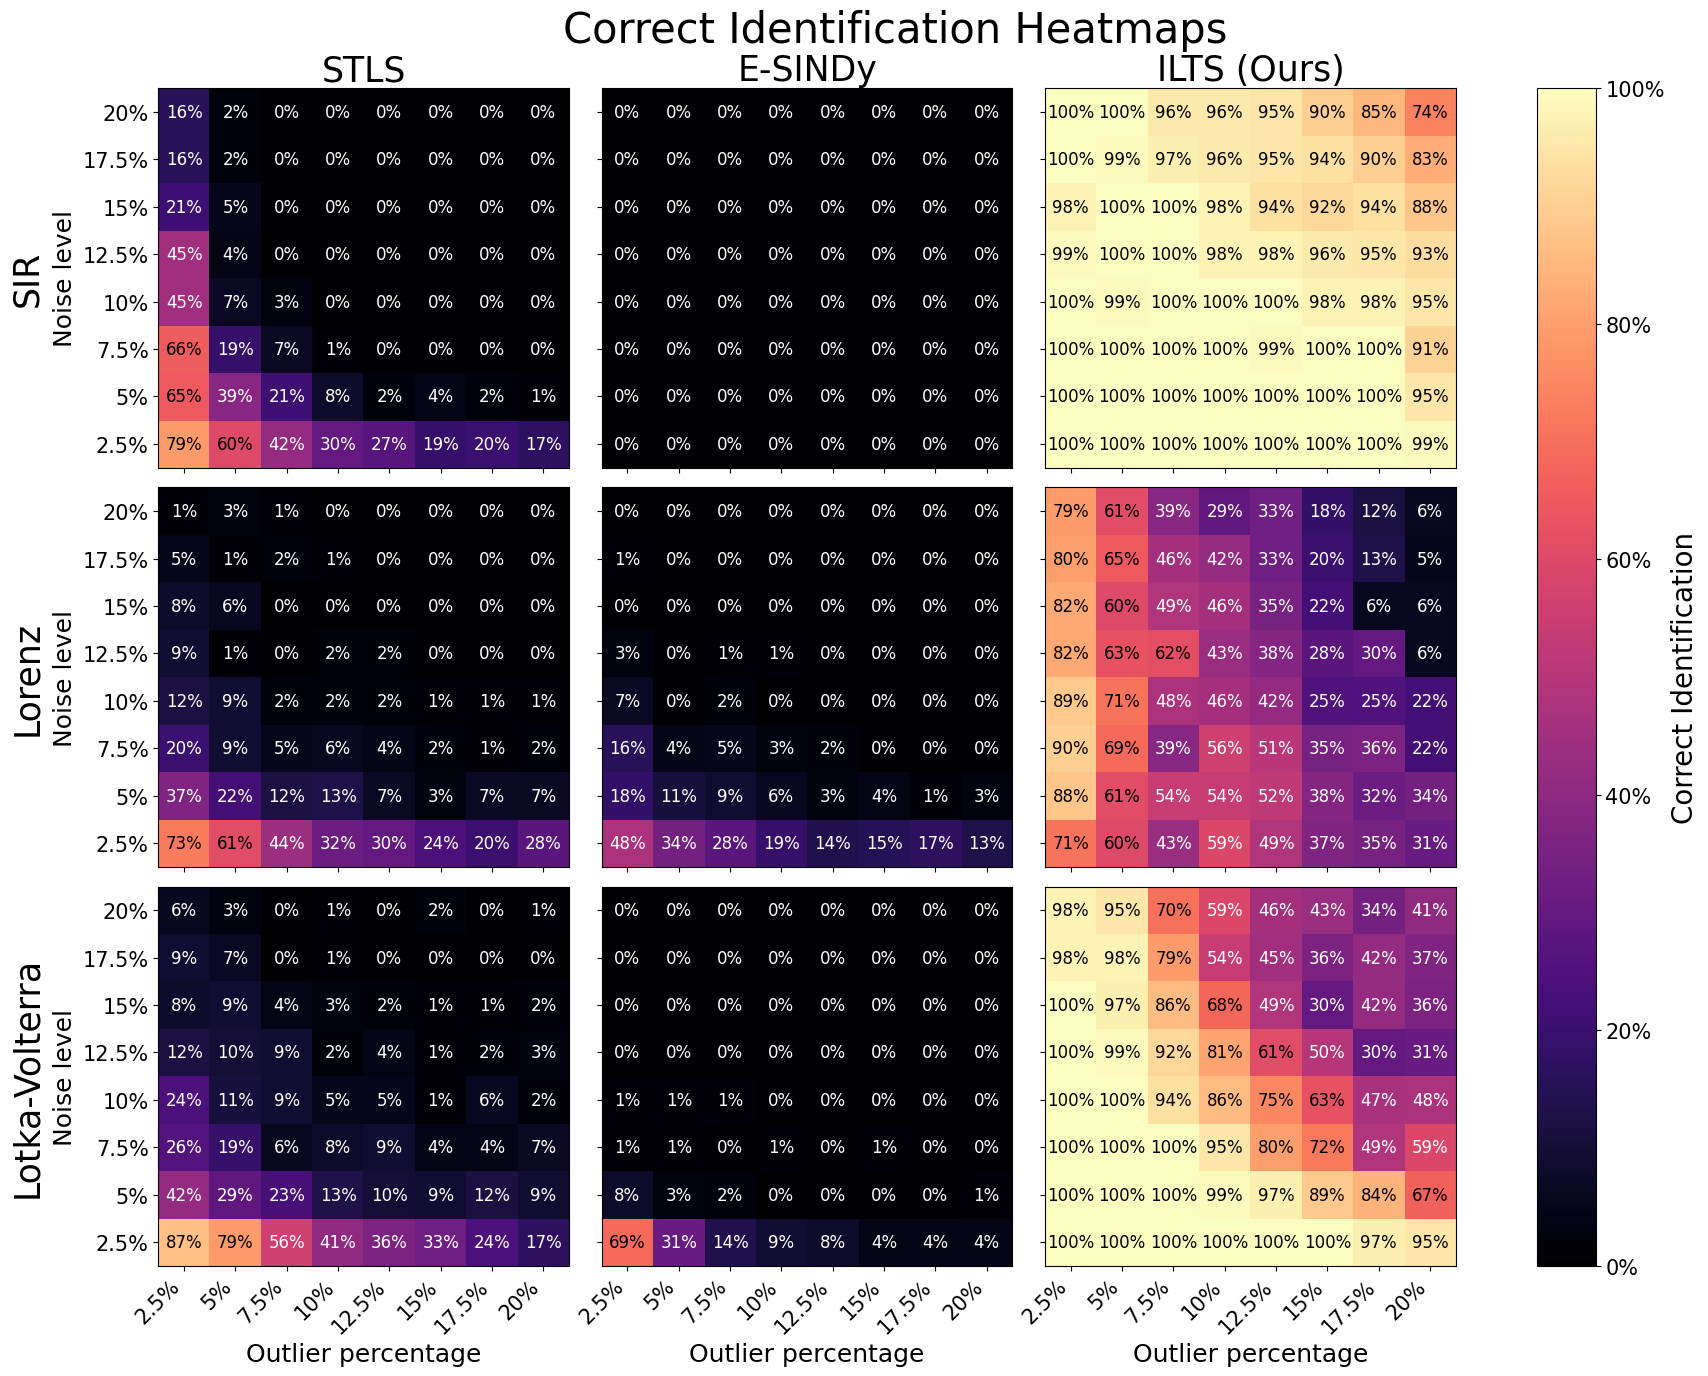

In [11]:
# Heatmap grid: rows = models, columns = solvers
solver_names = ['STLS', 'E-SINDy', 'ILTS (Ours)']
model_names = ['SIR', 'Lorenz', 'Lotka-Volterra']

fig, axes = plt.subplots(len(models), len(solvers), figsize=(18, 14), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for m_idx, model_name in enumerate(model_names):
    for s_idx, solver_name in enumerate(solver_names):
        ax = axes[m_idx, s_idx]
        acc = results_matrix_hits[m_idx, s_idx]  # shape (8, 8)

        im = ax.imshow(acc, origin="lower", cmap="magma", vmin=0, vmax=1, aspect="auto")

        ax.set_xticks(np.arange(len(outlier_list)))
        ax.set_xticklabels([f"{v*100:g}%" for v in outlier_list], rotation=45, ha="right", fontsize=15)

        ax.set_yticks(np.arange(len(noise_list)))
        ax.set_yticklabels([f"{v*100:g}%" for v in noise_list], fontsize=15)

        if m_idx == len(models) - 1:
            ax.set_xlabel("Outlier percentage", fontsize=18)
        if s_idx == 0:
            ax.set_ylabel("Noise level", fontsize=18)
            ax.text(
                -0.32, 0.5, model_name,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center",
                fontsize=25
            )

        if m_idx == 0:
            ax.set_title(solver_name, fontsize=25)

        for r in range(acc.shape[0]):
            for c in range(acc.shape[1]):
                v = acc[r, c]
                ax.text(c, r, f"{v*100:g}%", ha="center", va="center", fontsize=12, color="white" if v < 0.6 else "black")

fig.suptitle("Correct Identification Heatmaps", fontsize=30)
fig.tight_layout()

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label="Accuracy")
cbar.set_ticks(np.linspace(0, 1, 6))
cbar.set_ticklabels([f"{int(t*100)}%" for t in np.linspace(0, 1, 6)])
cbar.ax.tick_params(labelsize=15)
cbar.set_label("Correct Identification", size=20)

fig.savefig(f"paper_figs/heatmap/heatmap_hits_all_models_{nsamples}_samples.pdf", format="pdf",bbox_inches='tight')
plt.show()

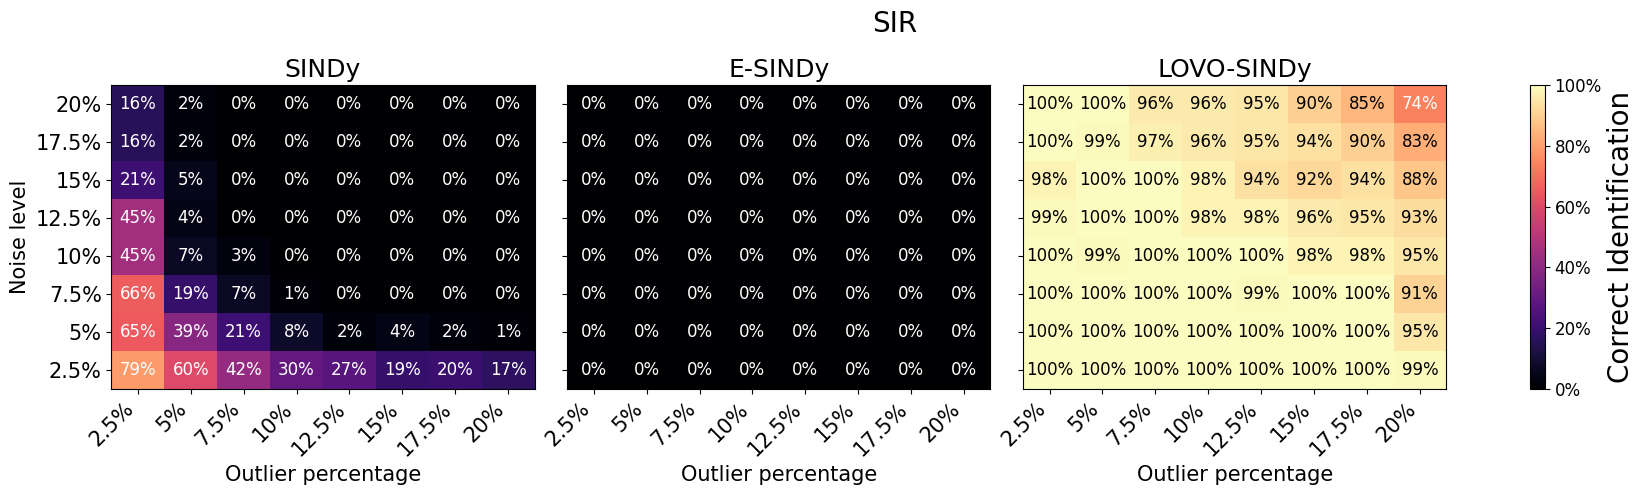

In [149]:
# Heatmap of SINDy accuracy vs noise level and outlier percentage

fig_all, axes = plt.subplots(1, len(solvers), figsize=(6 * len(solvers), 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
solver_names = ['SINDy', 'E-SINDy', 'LOVO-SINDy']
model_name = 'Lotka-Volterra' if model == 'LV' else model
for s_idx, (ax_i, s_name) in enumerate(zip(axes, solver_names)):
    acc_i = results_matrix_hits[s_idx]
    im_i = ax_i.imshow(acc_i, origin="lower", cmap="magma", vmin=0, vmax=1, aspect="auto")

    ax_i.set_xticks(np.arange(len(outlier_list)))
    ax_i.set_xticklabels([f"{v*100:g}%" for v in outlier_list], rotation=45, ha="right", fontsize=15)
    ax_i.set_yticks(np.arange(len(noise_list)))
    ax_i.set_yticklabels([f"{v*100:g}%" for v in noise_list], fontsize=15)

    ax_i.set_xlabel("Outlier percentage", fontsize = 15)
    if s_idx == 0:
        ax_i.set_ylabel("Noise level", fontsize = 15)
    ax_i.set_title(f"{s_name}", fontsize = 18)

    for r in range(acc_i.shape[0]):
        for c in range(acc_i.shape[1]):
            v = acc_i[r, c]
            ax_i.text(c, r, f"{v*100:g}%", ha="center", va="center", fontsize=12, color="white" if v < 0.8 else "black")

fig_all.suptitle(model_name, fontsize=20)
fig_all.tight_layout()
cbar = fig_all.colorbar(im_i, ax=axes.ravel().tolist(), label="Correct Identification")
cbar.set_ticks(np.linspace(0, 1, 6))
cbar.set_ticklabels([f"{int(t*100)}%" for t in np.linspace(0, 1, 6)])
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Correct Identification', size=20)
fig_all.savefig(f'paper_figs/heatmap/heatmap_hits_{model.lower()}_{nsamples}_samples.pdf', format='pdf')
plt.show()

## Outlier Detection Order for LOVO LS

In [6]:
noise_list = np.linspace(0,0.2,9)[1:]
outlier_list = np.linspace(0,0.2,9)[1:]
models = ['SIR', 'LORENZ', 'LV']
nsamples = 100
hist_detection = np.zeros((3,8,8,nsamples, 1001,3), dtype=float)
solver = 'LOVO_LS'
p = 1



for m, model in enumerate(models):
    coeffs_file = np.load(
        f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz',
        allow_pickle=True
    )
    data_file = np.load(
        f'data/{model}_heatmap_{nsamples}_data.npz',
        allow_pickle=True
    )

    for i, nl in enumerate(noise_list):
        for j, op in enumerate(outlier_list):
            data, data_outlier = load_data(data_file, nl, op)

            der_outlier = np.array([
                [(xi.item() - 1, xi.item() + 1) for xi in out_k]
                for out_k in data_outlier
            ], dtype=object).reshape((100, -1))

            _, td = load_heatmap_coeff(coeffs_file, nl, op, is_lovo=True)

            for k_sample, (tdi, data_out_i, der_out_i) in enumerate(
                zip(td, data_outlier, der_outlier)
            ):
                out_set = set(np.ravel(data_out_i))
                der_set = set(np.ravel(der_out_i))

                g = np.empty(tdi.shape, dtype=int)
                for idx, val in np.ndenumerate(tdi):
                    if val in out_set:
                        g[idx] = 1
                    elif val in der_set:
                        g[idx] = 2
                    else:
                        g[idx] = 3

                hist_detection[m, i, j, k_sample, :, :tdi.shape[1]] = g

# for m, model in enumerate(models):
#     coeffs_file = np.load(f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz', allow_pickle=True)
#     for i, nl in enumerate(noise_list):
#         for j, op in enumerate(outlier_list):
#             data_file = np.load(f'data/{model}_heatmap_{nsamples}_data.npz', allow_pickle=True)
#             data,data_outlier = load_data(data_file,nl,op)
#             der_outlier = np.array([[(xi.item() -1, xi.item() + 1) for xi in out_k] for out_k in data_outlier]).reshape((100,-1))
#             _, td = load_heatmap_coeff(coeffs_file, nl, op, is_lovo=True)
#             for tdi, data_out_i, der_out_i in zip(td, data_outlier, der_outlier):
#                 for k in range(tdi.shape[0]):
#                     for n in range(tdi.shape[1]):
#                         if tdi[k,n] in data_out_i:
#                             g = 1
#                         elif tdi[k,n] in der_out_i:
#                             g = 2
                        # else:
                        #     g = 3
                        # hist_detection[m,i,j,k,n] = g



In [14]:
def class_outlier(data, out_set, der_set, n_in):
    # data: ranked indices, shape (n_points, n_dims) or (n_points,)
    idx = np.asarray(data, dtype=int)
    if idx.ndim == 1:
        idx = idx[:, None]

    n_points = idx.shape[0]
    n_in = int(np.clip(n_in, 0, n_points))

    is_data_out = np.isin(idx, list(out_set))
    is_der_out = np.isin(idx, list(der_set))

    g = np.empty(idx.shape, dtype=int)

    inlier_region = np.zeros((n_points, 1), dtype=bool)
    inlier_region[:n_in] = True
    outlier_region = ~inlier_region

    both = is_data_out & is_der_out
    data_only = is_data_out & ~is_der_out
    der_only = ~is_data_out & is_der_out
    neither = ~is_data_out & ~is_der_out

    # Before threshold (should be inliers)
    g[inlier_region & both] = -1
    g[inlier_region & data_only] = -2
    g[inlier_region & der_only] = -3
    g[inlier_region & neither] = 4

    # After threshold (selected as outliers)
    g[outlier_region & both] = 1
    g[outlier_region & data_only] = 2
    g[outlier_region & der_only] = 3
    g[outlier_region & neither] = -4

    return g

def get_outliers_detections(p, nsamples= 100):
    noise_list = np.linspace(0,0.2,9)[1:]
    outlier_list = np.linspace(0,0.2,9)[1:]
    models = ['SIR', 'LORENZ', 'LV']
    detected_label = np.zeros((3,8,8,nsamples, 1001,3), dtype=float)
    solver = 'LOVO_LS'

    for m, model in enumerate(models):
        coeffs_file = np.load(
            f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz',
            allow_pickle=True
        )
        data_file = np.load(
            f'data/{model}_heatmap_{nsamples}_data.npz',
            allow_pickle=True
        )

        for i, nl in enumerate(noise_list):
            for j, op in enumerate(outlier_list):
                _, data_outlier = load_data(data_file, nl, op)

                der_outlier = np.array([
                    [(xi.item() - 1, xi.item() + 1) for xi in out_k]
                    for out_k in data_outlier
                ], dtype=object).reshape((100, -1))

                _, td = load_heatmap_coeff(coeffs_file, nl, op, is_lovo=True)


                for k_sample, (tdi, data_out_i, der_out_i) in enumerate(
                    zip(td, data_outlier, der_outlier)
                ):
                    out_set = set(np.ravel(data_out_i))
                    der_set = set(np.ravel(der_out_i))
                    all_out = der_set.union(out_set)
                    n_in = 1001 - len(all_out)
                    g = class_outlier(tdi, out_set, der_set, n_in)
                    detected_label[m, i, j, k_sample, :, :tdi.shape[1]] = g
    detected_label[detected_label == 0] = np.nan
    return detected_label

In [13]:
labels_1p = get_outliers_detections(1)
labels_2p = get_outliers_detections(2)
labels_3p = get_outliers_detections(3)
labels_4p = get_outliers_detections(4)
labels_T = get_outliers_detections(-1)

In [15]:
def get_statistics(labels, case = 'all'):
    if case == 'all':
        tp = (labels == 1) + (labels == 2) + (labels == 3)
        fn = (labels == -1) + (labels == -2) + (labels == -3)
    elif case == 'data':
        tp = (labels == 1) + (labels == 2)
        fn = (labels == -1) + (labels == -2)
    elif case == 'der':
        tp = (labels == 1) + (labels == 3)
        fn = (labels == -1) + (labels == -3)
    else:
        raise ValueError(f"Invalid method: {case}. Supported methods are: 'all', 'data', 'der'.")

    tn = (labels == 4)
    fp = (labels == -4)
    return tp, tn, fp, fn


# def agregate_stats(tp,tn,fp, fn, method = 'acc'):
#     sum_axes = tuple(range(1, tp.ndim))

def sum_stats(tp, tn, fp, fn, sum_axes):
    tp_sum = np.nansum(tp, axis=sum_axes)
    tn_sum = np.nansum(tn, axis=sum_axes)
    fp_sum = np.nansum(fp, axis=sum_axes)
    fn_sum = np.nansum(fn, axis=sum_axes)

    return tp_sum, tn_sum, fp_sum, fn_sum

def calc_metric(tp_sum, tn_sum, fp_sum, fn_sum, metric):
    if metric == 'acc':
        res = (tp_sum + tn_sum) / (tp_sum + tn_sum + fp_sum + fn_sum)
    elif metric == 'precision':
        res = tp_sum / (tp_sum + fp_sum)
    elif metric == 'recall':
        res = tp_sum / (tp_sum + fn_sum)
    elif metric == 'f1':
        res = (2 * tp_sum) / (2 * tp_sum + fn_sum + fp_sum)
    else:
        raise ValueError(
            f"Invalid metric: {metric}. Supported methods are: 'acc', 'precision', 'recall', 'f1'."
        )
    return res

def agregate_stats(tp, tn, fp, fn, metric='acc', return_std=False):
    # Aggregate over time/dimension axes, keep model/noise/outlier/sample axes
    sum_axes = tuple(range(4, tp.ndim))
    tp_sum, tn_sum, fp_sum, fn_sum = sum_stats(tp, tn, fp, fn, sum_axes)
    res = calc_metric(tp_sum, tn_sum, fp_sum, fn_sum, metric)

    # mean over realizations first
    res_mean = res.mean(axis=3)

    # then average conditions
    res_mean_problem = res_mean.mean(axis=(1,2))

    # std over realizations, then average
    res_std_problem = res.std(axis=3).mean(axis=(1,2))
    return (res_mean_problem, res_std_problem) if return_std else res_std_problem

In [15]:
case = 'all'
stats_1p = get_statistics(labels_1p, case=case)
stats_2p = get_statistics(labels_2p, case=case)
stats_3p = get_statistics(labels_3p, case=case)
stats_4p = get_statistics(labels_4p, case=case)
stats_T = get_statistics(labels_T, case=case)


In [16]:
met = 'recall'
results_1p, std_1p = agregate_stats(*stats_1p, metric=met, return_std=True)
results_2p, std_2p = agregate_stats(*stats_2p, metric=met, return_std=True)
results_3p, std_3p = agregate_stats(*stats_3p, metric=met, return_std=True)
results_4p, std_4p = agregate_stats(*stats_4p, metric=met, return_std=True)
results_T, std_T = agregate_stats(*stats_T, metric=met, return_std=True)

results = (results_1p, results_2p, results_3p, results_4p, results_T)
std = (std_1p, std_2p, std_3p, std_4p, std_T)
print(met)
for r,s in zip(results, std):
    for a,b in zip(r,s):
        print(f'${a:.3f} \\pm {b:.3f}$ ', end='\t')
    print()

recall
$0.871 \pm 0.032$ 	$0.884 \pm 0.013$ 	$0.877 \pm 0.018$ 	
$0.952 \pm 0.010$ 	$0.931 \pm 0.010$ 	$0.923 \pm 0.011$ 	
$0.961 \pm 0.013$ 	$0.939 \pm 0.010$ 	$0.918 \pm 0.017$ 	
$0.954 \pm 0.020$ 	$0.926 \pm 0.012$ 	$0.898 \pm 0.025$ 	
$0.964 \pm 0.011$ 	$0.943 \pm 0.009$ 	$0.929 \pm 0.014$ 	


In [ ]:
# Select experiment:
noise_list = np.linspace(0,0.2,9)[1:]
outlier_list = np.linspace(0,0.2,9)[1:]
models = ['SIR', 'LORENZ', 'LV']
nsamples = 100

opi = 7
nli = 7
simi = 0

nl = noise_list[nli]
op = outlier_list[opi]
p = 3
class_list = []
index_list = []
data_list = []
for m, model in enumerate(models):
    coeffs_file = np.load(
        f'coeffs_heatmap/{model}_{solver}_{p}P_{nsamples}_samples.npz',
        allow_pickle=True
    )
    data_file = np.load(
        f'data/{model}_heatmap_{nsamples}_data.npz',
        allow_pickle=True
    )

    data, data_outlier = load_data(data_file, nl, op)
    der_outlier = np.array([
        [(xi.item() - 1, xi.item() + 1) for xi in out_k]
        for out_k in data_outlier
    ], dtype=object).reshape((100, -1))

    _, td = load_heatmap_coeff(coeffs_file, nl, op, is_lovo=True)
    n_in = 1001 - int(data_outlier.shape[1]*p)

    td = td[simi]
    data_list.append(data[simi])
    data_outlier = data_outlier[simi]
    der_outlier = der_outlier[simi]

    out_set = set(np.ravel(data_outlier))
    der_set = set(np.ravel(der_outlier))

    g = class_outlier(td, out_set, der_set, n_in)
    class_list.append(g)
    index_list.append(td)

In [240]:
# Plot results:

class_style = {
    1:  ("tab:blue", "o", "Data outlier (selected)"),
    2:  ("tab:orange", "o", "Deriv. outlier (selected)"),
    3:  ("tab:green", ".", "Inlier"),
    -1: ("crimson", "x", "Data outlier (missed)"),
    -2: ("darkred", "x", "Deriv. outlier (missed)"),
    -3: ("purple", "x", "False Outlier"),
}
# Rebuild figure as a 3x3 grid: rows=models, cols=dimensions (max=3)
max_dims = 3
model_names = ['SIR', 'Lorenz', 'Lotka-Volterra']
for m,case in enumerate(models):
        model_name = model_names[m]
        # Get data
        X = np.asarray(data_list[m])   # (1001, n_dims)
        n_dims = X.shape[1]
        fig, axes = plt.subplots(n_dims,2, figsize=(16, 8), sharex=True)
        t_span = T_DCT[case.upper()]
        tt = np.linspace(*t_span,1001)
        dX = ps.FiniteDifference()._differentiate(X, tt)


        ## Get Classes
        G = np.asarray(class_list[m])        # (1001, n_dims)
        C = np.asarray(index_list[m])

        ## Get Inliners (TN):
        inliner_mask = (G == 4)

        ## Get True Positive
        tp_mask_data = (G == 1) + (G == 2)
        tp_mask_der = (G == 1) + (G == 3)
        
        ## Get False Positive
        fp_mask = (G == -4)
        
        ## Get False Negative
        fn_mask_data = (G == -1) + (G == -2)
        fn_mask_der = (G == -1) + (G == -3)

        for d in range(n_dims):
                inliner_index_i = C[inliner_mask[:,d], d]
                inliner_index_i = np.sort(np.asarray(inliner_index_i, dtype=int))
                inliner_data = X[inliner_index_i,d]
                inliner_der = dX[inliner_index_i,d]
                axes[d,0].plot(tt[inliner_index_i], inliner_data, 'b.', label = 'Inliners')
                axes[d,1].plot(tt[inliner_index_i], inliner_der, 'b.', label = 'Inliners')

                tp_index_data = C[tp_mask_data[:,d], d]
                tp_index_data = np.sort(np.asarray(tp_index_data, dtype=int))
                tp_index_der = C[tp_mask_der[:,d], d]
                tp_index_der = np.sort(np.asarray(tp_index_der, dtype=int))

                tp_data = X[tp_index_data,d]
                tp_der = dX[tp_index_der,d]
                axes[d,0].plot(tt[tp_index_data], tp_data, 'go', label = 'Correct Outlier Detection', alpha=0.5)
                axes[d,1].plot(tt[tp_index_der], tp_der, 'go', label = 'Correct Outlier Detection', alpha=0.5)

                fp_index_i = C[fp_mask[:,d], d]
                fp_index_i = np.sort(np.asarray(fp_index_i, dtype=int))
                fp_data = X[fp_index_i,d]
                fp_der = dX[fp_index_i,d]
                axes[d,0].plot(tt[fp_index_i], fp_data, 'yv', label = 'Wrong Outlier Detection', ms = 7, alpha = 0.7)
                axes[d,1].plot(tt[fp_index_i], fp_der, 'yv', label = 'Wrong Outlier Detection', ms = 7, alpha = 0.7)

                fn_index_data = C[fn_mask_data[:,d], d]
                fn_index_data = np.sort(np.asarray(fn_index_data, dtype=int))

                fn_index_der = C[fn_mask_der[:,d], d]
                fn_index_der = np.sort(np.asarray(fn_index_der, dtype=int))
                fn_data = X[fn_index_data,d]
                fn_der = dX[fn_index_der,d]
                axes[d,0].plot(tt[fn_index_data], fn_data, 'rx', label = 'Missed Outlier', ms = 10, mew=3)
                axes[d,1].plot(tt[fn_index_der], fn_der, 'rx', label = 'Missed Outlier', ms = 10, mew=3)

                # Base trajectory for this dimension
        dim_labels = {
            'SIR': ['S', 'I', 'R'],
            'LORENZ': ['x', 'y', 'z'],
            'LV': ['prey', 'predator'],
        }[case.upper()]

        for d in range(n_dims):
            axes[d, 0].set_ylabel(dim_labels[d], fontsize=18)
            if d == n_dims - 1:
                axes[d, 0].set_xlabel('t', fontsize=18)
                axes[d, 1].set_xlabel('t', fontsize=18)
        axes[0,0].set_title('Original Data', fontsize=22)
        axes[0,1].set_title('Numerical Derivative', fontsize=22)
        for ax in np.ravel(axes):
            ax.tick_params(axis="both", labelsize=15)
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.05),
        frameon=True,
        fontsize=20,
        )

        fig.suptitle(f'{model_name}', fontsize=30)
        fig.savefig(
            f"paper_figs/outlier_detection/{model_name}_noise{nl:g}_outlier{op:g}_samples{nsamples}_sample_{simi}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.close(fig)


In [12]:

def get_q_sweep(noise_level, outlier_percent, nsamples):

    models = ['SIR', 'LORENZ', 'LV']
    nq =  int(4004*outlier_percent)- int(1001*outlier_percent) + 1
    detected_label = np.zeros((3,nq, nsamples, 1001,3), dtype=float)

    for m, model in enumerate(models):
        coeffs_file = np.load(
            f'coeffs_heatmap/q_sweep_{model}_{nsamples}_samples_nl_{noise_level:g}_op_{outlier_percent:g}.npz',
            allow_pickle=True
        )
        data_file = np.load(
            f'data/{model}_heatmap_{nsamples}_data.npz',
            allow_pickle=True
        )

        _, data_outlier = load_data(data_file, noise_level, outlier_percent)

        der_outlier = np.array([
            [(xi.item() - 1, xi.item() + 1) for xi in out_k]
            for out_k in data_outlier
        ], dtype=object).reshape((100, -1))

        td = coeffs_file['outliers']
        for k_sample, (tdi, data_out_i, der_out_i) in enumerate(
            zip(td, data_outlier, der_outlier)
        ):
            out_set = set(np.ravel(data_out_i))
            der_set = set(np.ravel(der_out_i))
            all_out = der_set.union(out_set)
            n_in = 1001 - len(all_out)
            for i, qi in enumerate(tdi):
                g = class_outlier(qi, out_set, der_set, n_in)
                detected_label[m, i, k_sample, :, :qi.shape[1]] = g
    detected_label[detected_label == 0] = np.nan
    return detected_label

In [27]:
nl = 0.1
op = 0.1
detected_label = get_q_sweep(nl, op, 100)
q_sweep_stats = get_statistics(detected_label, case = 'all')

In [28]:
sum_axis = (3,4)
sum_stats_q = sum_stats(*q_sweep_stats, sum_axes = sum_axis)
metrics_q = calc_metric(*sum_stats_q, metric='recall')
mean_metric = metrics_q.mean(axis=2)

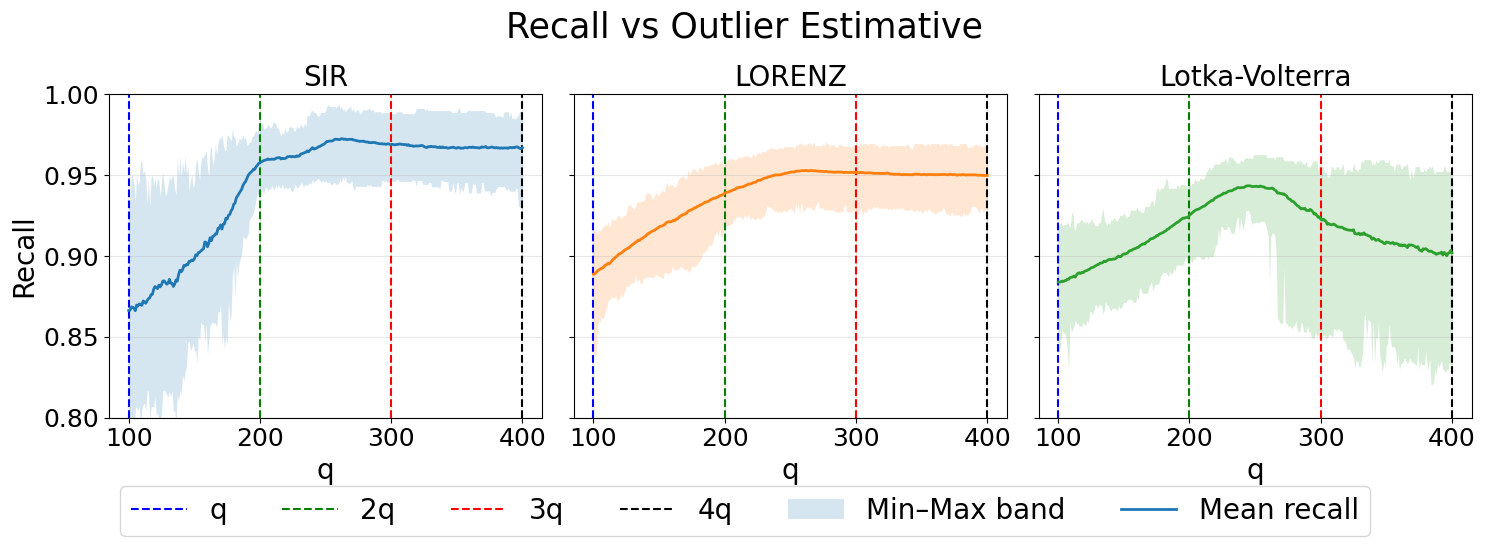

In [38]:
q_min = int(1001 * op)
q_max = int(4004 * op)
q_axis = np.arange(q_min, q_max + 1)

q_min_band = metrics_q.min(axis=2)   # (3, n_q)
q_max_band = metrics_q.max(axis=2)   # (3, n_q)

model_names = ['SIR', 'LORENZ', 'Lotka-Volterra']
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for m, ax in enumerate(axes):
    ax.axvline(q_min, color='b', linestyle='--', label='q')
    ax.axvline(q_min * 2, color='g', linestyle='--', label='2q')
    ax.axvline(q_min * 3, color='r', linestyle='--', label='3q')
    ax.axvline(q_min * 4, color='k', linestyle='--', label='4q')
    
    ax.fill_between(
        q_axis,
        q_min_band[m],
        q_max_band[m],
        color=colors[m],
        alpha=0.18,
        linewidth=0,
        label='Min–Max band'
    )
    ax.plot(q_axis, mean_metric[m], color=colors[m], lw=2, label='Mean recall')
    axes[m].set_xlabel('q', fontsize=20)


    ax.set_title(model_names[m], fontsize=20)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.8, 1.0)

    
axes[0].set_ylabel('Recall', fontsize=20)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fontsize=20,
)
for ax in axes:
    ax.tick_params(axis='both', labelsize=18)
fig.suptitle('Recall vs Outlier Estimative', fontsize=25)
fig.tight_layout()
fig.savefig(f'paper_figs/outlier_detection/q_sweep_nl{nl:g}_op{op:g}.pdf',
             format='pdf', bbox_inches="tight")

In [ ]:
## Load Data

case = 'SIR'
outlier_level = 0.10
t_span = T_DCT[case.upper()]

data = np.load(f'data_single/{case.upper()}_outliers.npz', allow_pickle=True)
t = np.linspace(*t_span, 1001)
all_data = data[f'data'][OUT_DCT[outlier_level]]
out_data = data[f'outliers'][OUT_DCT[outlier_level]]
out_der = np.zeros_like(out_data, dtype=bool)
out_der_index = np.unique(np.array([(i-1, i+1) for i in np.argwhere(out_data)]))
out_der[out_der_index] = True
data_outlier = all_data[out_data]
d_data = ps.FiniteDifference()._differentiate(all_data, t)

plot_data(all_data, data_outlier,t, case.upper())

result = np.load(f'coeffs_single/{case.upper()}_LOVO_LS_3P.npz', allow_pickle=True)
plot_res = result[f'simulations{outlier_level*100:g}']
true_lovo = result[f'outliers_{outlier_level*100:g}'].astype(int)
out_lovo = np.array([[ti not in true_lovo[:,i] for ti in range(1001)] for i in range(all_data.shape[1])])
all_out = out_data + out_der
correct_identification = (out_lovo * all_out).sum(1)

print(f'For {case} with {outlier_level*100}% of outliers:')
for i, c in enumerate(correct_identification):
    print(f'\tLOVO identified {c} true outliers of {all_out.sum()}({c/all_out.sum() *100}%) on dimension {i}')
plot_data(d_data[out_der], out_lovo[0][out_der],t[out_der], case.upper())
plot_data(all_data[out_data], out_lovo[0][out_data],t[out_data], case.upper())

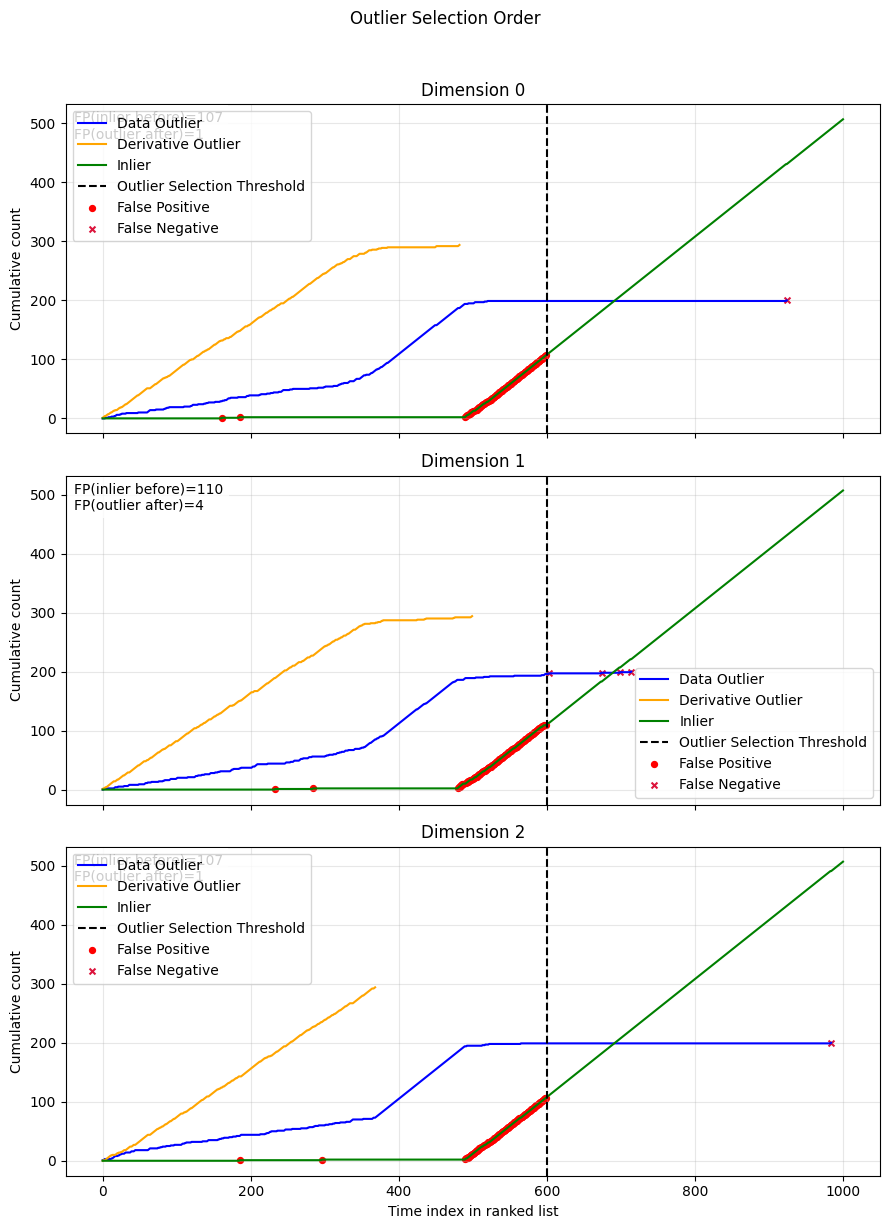

In [30]:
# choose one configuration
m = 0      # model index
i = 5      # noise level index
j = 7      # outlier percentage index
s = 0      # sample index

out_end = int(1001 * outlier_list[j] * p)

H = hist_detection[m, i, j, s]   # shape: (1001, n_dims)
H = H[::-1]                      # reverse ranking order
t = np.arange(H.shape[0])

n_dims = H.shape[1]
fig, axes = plt.subplots(n_dims, 1, figsize=(9, 4 * n_dims), sharex=True)
axes = np.atleast_1d(axes)

for d, ax in enumerate(axes):
    Hd = H[:, d]

    count_g1 = (Hd == 1).astype(int)  # Data outlier
    count_g2 = (Hd == 2).astype(int)  # Derivative outlier
    count_g3 = (Hd == 3).astype(int)  # Inlier

    cum_g1 = np.cumsum(count_g1).astype(float)
    cum_g2 = np.cumsum(count_g2).astype(float)
    cum_g3 = np.cumsum(count_g3).astype(float)

    end_g1 = np.argmax(cum_g1 == cum_g1[-1])
    end_g2 = np.argmax(cum_g2 == cum_g2[-1])
    end_g3 = np.argmax(cum_g3 == cum_g3[-1])

    cum_g1[end_g1 + 1:] = np.nan
    cum_g2[end_g2 + 1:] = np.nan
    cum_g3[end_g3 + 1:] = np.nan

    ax.plot(t, cum_g1, 'b', label='Data Outlier')
    ax.plot(t, cum_g2, color='orange', label='Derivative Outlier')
    ax.plot(t, cum_g3, 'g', label='Inlier')
    ax.axvline(out_end, color='k', linestyle='--', linewidth=1.5, label='Outlier Selection Threshold')
    # False positives:
    # 1) inliers selected before threshold
    fp_inlier_before = (Hd == 3) & (t < out_end)

    # 2) outliers appearing after threshold
    fp_data_after = (Hd == 1) & (t > out_end)
    fp_der_after = (Hd == 2) & (t > out_end)

    if np.any(fp_inlier_before):
        ax.scatter(
            t[fp_inlier_before], cum_g3[fp_inlier_before],
            c="red", s=18, marker="o", label="False Positive"
        )

    if np.any(fp_data_after):
        ax.scatter(
            t[fp_data_after], cum_g1[fp_data_after],
            c="crimson", s=18, marker="x", label="False Negative"
        )

    if np.any(fp_der_after):
        ax.scatter(
            t[fp_der_after], cum_g2[fp_der_after],
            c="darkred", s=18, marker="x", label="False Negative"
        )

    n_fp1 = int(fp_inlier_before.sum())
    n_fp2 = int(fp_data_after.sum() + fp_der_after.sum())
    ax.text(
        0.01, 0.98, f"FP(inlier before)={n_fp1}\nFP(outlier after)={n_fp2}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=10, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )
    ax.set_ylabel('Cumulative count')
    ax.set_title(f'Dimension {d}')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Time index in ranked list')
fig.suptitle('Outlier Selection Order', y=1.02)
plt.tight_layout()
plt.show()

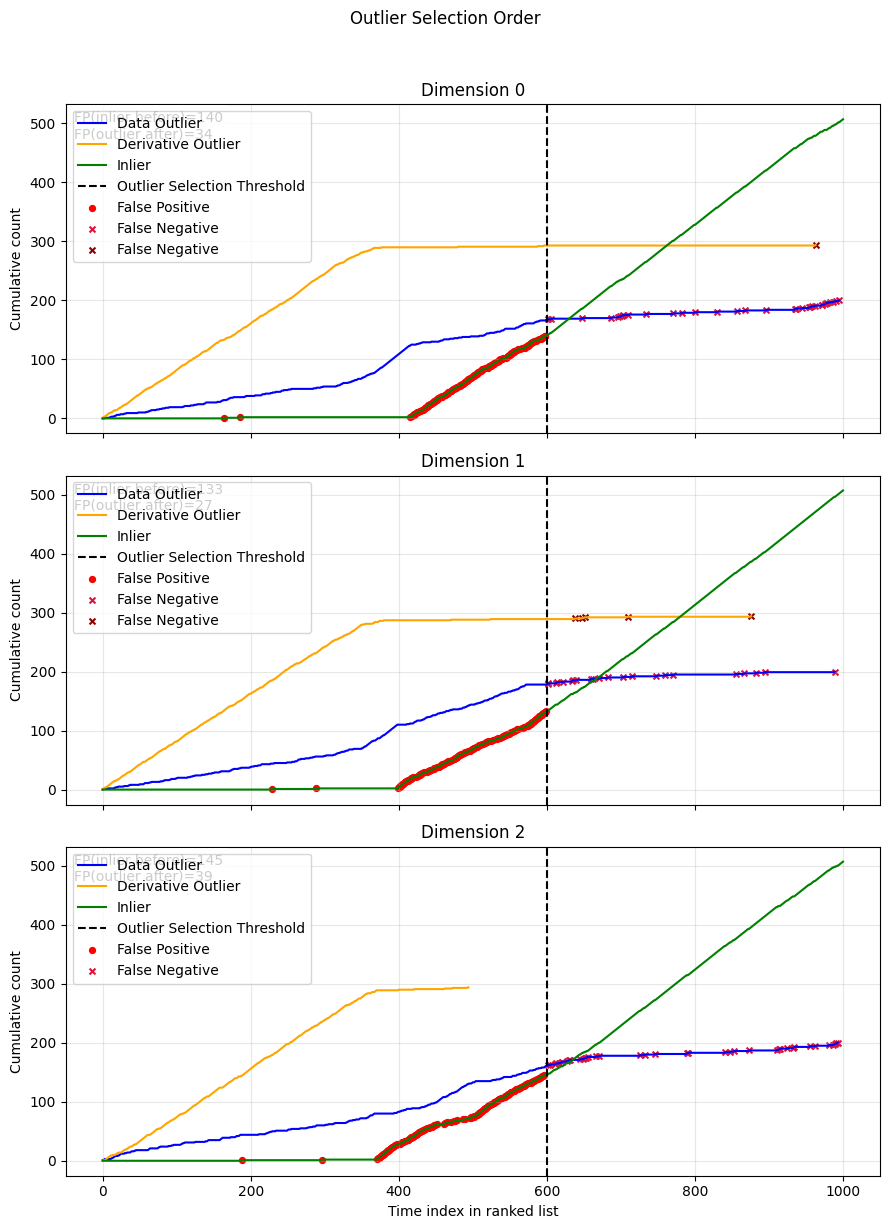

In [33]:
# choose one configuration
m = 0      # model index
i = 5      # noise level index
j = 7      # outlier percentage index
s = 0      # sample index

out_end = int(1001 * outlier_list[j] * 3)

H = hist_detection[m, i, j, s]   # shape: (1001, n_dims)
H = H[::-1]                      # reverse ranking order
t = np.arange(H.shape[0])

n_dims = H.shape[1]
fig, axes = plt.subplots(n_dims, 1, figsize=(9, 4 * n_dims), sharex=True)
axes = np.atleast_1d(axes)

for d, ax in enumerate(axes):
    Hd = H[:, d]

    count_g1 = (Hd == 1).astype(int)  # Data outlier
    count_g2 = (Hd == 2).astype(int)  # Derivative outlier
    count_g3 = (Hd == 3).astype(int)  # Inlier

    cum_g1 = np.cumsum(count_g1).astype(float)
    cum_g2 = np.cumsum(count_g2).astype(float)
    cum_g3 = np.cumsum(count_g3).astype(float)

    end_g1 = np.argmax(cum_g1 == cum_g1[-1])
    end_g2 = np.argmax(cum_g2 == cum_g2[-1])
    end_g3 = np.argmax(cum_g3 == cum_g3[-1])

    cum_g1[end_g1 + 1:] = np.nan
    cum_g2[end_g2 + 1:] = np.nan
    cum_g3[end_g3 + 1:] = np.nan

    ax.plot(t, cum_g1, 'b', label='Data Outlier')
    ax.plot(t, cum_g2, color='orange', label='Derivative Outlier')
    ax.plot(t, cum_g3, 'g', label='Inlier')
    ax.axvline(out_end, color='k', linestyle='--', linewidth=1.5, label='Outlier Selection Threshold')
    # False positives:
    # 1) inliers selected before threshold
    fp_inlier_before = (Hd == 3) & (t < out_end)

    # 2) outliers appearing after threshold
    fp_data_after = (Hd == 1) & (t > out_end)
    fp_der_after = (Hd == 2) & (t > out_end)

    if np.any(fp_inlier_before):
        ax.scatter(
            t[fp_inlier_before], cum_g3[fp_inlier_before],
            c="red", s=18, marker="o", label="False Positive"
        )

    if np.any(fp_data_after):
        ax.scatter(
            t[fp_data_after], cum_g1[fp_data_after],
            c="crimson", s=18, marker="x", label="False Negative"
        )

    if np.any(fp_der_after):
        ax.scatter(
            t[fp_der_after], cum_g2[fp_der_after],
            c="darkred", s=18, marker="x", label="False Negative"
        )

    n_fp1 = int(fp_inlier_before.sum())
    n_fp2 = int(fp_data_after.sum() + fp_der_after.sum())
    ax.text(
        0.01, 0.98, f"FP(inlier before)={n_fp1}\nFP(outlier after)={n_fp2}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=10, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )
    ax.set_ylabel('Cumulative count')
    ax.set_title(f'Dimension {d}')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Time index in ranked list')
fig.suptitle('Outlier Selection Order', y=1.02)
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
from fractions import Fraction
A = np.array([
    [1., 1, 1, 1, 1],
    [-2, -1, 0, 1, 2],
    [2, .5, 0, .5, 2],
    [-4/3, -1/6, 0, 1/6, 4/3],
    [2/3, 1/24, 0, 1/24, 2/3]
])

b = np.array([0,1,0,0,0])

c = np.linalg.solve(A,b)

print(c)
print([Fraction(x).limit_denominator() for x in c])

[ 0.08333333 -0.66666667  0.          0.66666667 -0.08333333]
[Fraction(1, 12), Fraction(-2, 3), Fraction(0, 1), Fraction(2, 3), Fraction(-1, 12)]


In [3]:
A = np.array([
    [1., 1, 1, 1],
    [0, 1, 2, 3],
    [0., .5, 2, 4.5],
    [0., 1/6, 4/3, 4.5],
])

b = np.array([0,1,0,0])

c = np.linalg.solve(A,b)

print(c)
print([Fraction(x).limit_denominator() for x in c])

[-1.83333333  3.         -1.5         0.33333333]
[Fraction(-11, 6), Fraction(3, 1), Fraction(-3, 2), Fraction(1, 3)]


In [4]:
A = np.array([
    [1., 1, 1, 1],
    [0, -1, -2, -3],
    [0., .5, 2, 4.5],
    [0., -1/6, -4/3, -4.5],
])

b = np.array([0,1,0,0])

c = np.linalg.solve(A,b)

print(c)
print([Fraction(x).limit_denominator() for x in c])

[ 1.83333333 -3.          1.5        -0.33333333]
[Fraction(11, 6), Fraction(-3, 1), Fraction(3, 2), Fraction(-1, 3)]
